In [24]:
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 生成600个样本
n_samples = 600

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房屋价格概率 (0-1之间的连续值)
# 这个概率可以理解为"房屋价值高于市场平均水平的概率"
z = (0.01 * (area - 100) +        # 面积影响
     0.1 * (bedrooms - 2.5) +     # 卧室数量影响
     -0.02 * (age - 10) +         # 房龄影响
     0.08 * (location - 6) +      # 地理位置影响
     0.5)                         # 偏置项

# 使用sigmoid函数将z映射到0-1范围
price_probability = 1 / (1 + np.exp(-z))

# 添加一些噪声，但保持在0-1范围内
noise = np.random.normal(0, 0.1, n_samples)
price_probability = price_probability + noise
price_probability = np.clip(price_probability, 0.01, 0.99)  # 确保在0-1之间

print("数据集信息：")
print(f"样本数量: {n_samples}")
print(f"特征数量: 4")
print(f"目标变量: 房屋价格概率 (0-1之间的连续值)")
print(f"目标变量范围: {price_probability.min():.3f} - {price_probability.max():.3f}")

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price_probability': price_probability
})

# 手动分割训练集和测试集
data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)

# 按70/30比例分割
split_idx = int(0.7 * len(data_shuffled))
data_train = data_shuffled[:split_idx]
data_test = data_shuffled[split_idx:]

print(f"\n训练集大小: {len(data_train)}")
print(f"测试集大小: {len(data_test)}")
print(f"训练集目标范围: {data_train['price_probability'].min():.3f} - {data_train['price_probability'].max():.3f}")
print(f"测试集目标范围: {data_test['price_probability'].min():.3f} - {data_test['price_probability'].max():.3f}")

print("\n训练集前5个样本：")
print(data_train.head().round(3))

数据集信息：
样本数量: 600
特征数量: 4
目标变量: 房屋价格概率 (0-1之间的连续值)
目标变量范围: 0.184 - 0.990

训练集大小: 420
测试集大小: 180
训练集目标范围: 0.232 - 0.990
测试集目标范围: 0.184 - 0.990

训练集前5个样本：
      area  bedrooms     age  location  price_probability
0   93.463         3   0.835     7.393              0.595
1  162.856         1  13.117     4.218              0.711
2  138.488         4   3.926     6.571              0.777
3   61.107         2  43.172     6.029              0.374
4   67.021         3   4.961     8.329              0.643


In [25]:
data_train.head()

,area,bedrooms,age,location,price_probability
0,93.462718,3,0.835064,7.392775,0.595477
1,162.856179,1,13.117455,4.217616,0.711453
2,138.487653,4,3.925626,6.571108,0.777458
3,61.106698,2,43.171827,6.029376,0.374071
4,67.021028,3,4.960709,8.329479,0.642660


In [26]:
import numpy as np
import pandas as pd


In [27]:
#get ready

In [28]:
def normalize(x):    #似乎与标准化也有关系，正常的标准化做的太离谱，s形状，但我这里不要S啊。/max /mean都试了
    return (x-x.mean())/x.std()

In [29]:
data_normalized=data_train.apply(normalize,axis=0)
data_normalized.head()

,area,bedrooms,age,location,price_probability
0,-0.676927,0.326601,-0.940249,0.620332,-0.564645
1,0.871285,-1.767634,0.289318,-0.990155,0.240827
2,0.327608,1.373719,-0.630858,0.203571,0.699243
3,-1.398810,-0.720517,3.298004,-0.071204,-2.102351
4,-1.266857,0.326601,-0.527238,1.095441,-0.236954


In [51]:
rng=np.random.default_rng(17)
primary_parameter={'power1':rng.random((4,8))*0.1,\
                   'threshold1':rng.random(8)*0.1,\
                   'power2':rng.random(8)*0.1,\
                   'threshold2':rng.random(1)*0.1}
print(primary_parameter)

{'power1': array([[0.08450748, 0.01609731, 0.05577445, 0.03680799, 0.0214942 ,
        0.0385824 , 0.04281645, 0.06113431],
       [0.07363859, 0.00152897, 0.02540409, 0.06041459, 0.00837367,
        0.09977637, 0.08323461, 0.00367774],
       [0.05675398, 0.06093401, 0.00069266, 0.01790839, 0.01649222,
        0.04619579, 0.05670036, 0.04519092],
       [0.09197757, 0.08149242, 0.04011661, 0.02031616, 0.03583255,
        0.0862035 , 0.03488156, 0.09910656]]), 'threshold1': array([0.05657688, 0.02368459, 0.06586973, 0.06602265, 0.05146076,
       0.0279093 , 0.06299182, 0.04791908]), 'power2': array([0.06532888, 0.05422403, 0.01212111, 0.0908738 , 0.00172133,
       0.03107606, 0.01713636, 0.034305  ]), 'threshold2': array([0.06175147])}


In [52]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [53]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [54]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [55]:
def standard_BP(data,primary_parameter,turn):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2-primary_parameter['threshold2'][0]    #why ?

    if turn%200==0:
        print(get_loss(y,y_hat))
    
    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter    

In [56]:
for j in range(20):
    for i in range(len(data_train)):
        primary_parameter=\
        standard_BP(data_normalized.iloc[i],primary_parameter,i)
print(primary_parameter)
        

0.2120843719124573
0.7303304399185353
0.24416413059790998
0.20165422123892143
1.5438099393446425
0.22218226939329427
0.21773684664523377
1.5904320836108035
0.19772791099982612
0.2317710589242316
1.5916424069788204
0.15739664198851053
0.2581868494776438
1.5804060110545826
0.09765006281567622
0.3125323565146882
1.6250197074146921
0.057831690090764
0.3755584359417453
1.7555324282837181
0.07678233973687319
0.3875068888618383
1.8869878206035926
0.19096613240842852
0.35793683219260053
1.3659881673345176
0.2284803226758575
0.34053407667206687
0.9152511025850721
0.244561241293563
0.265922989278192
0.9510825381448208
0.27099899499936697
0.23914014284293492
1.0106014314043268
0.2737923719198802
0.22962130511191292
1.0703244711303688
0.2652845060361866
0.22582520884401885
1.127535346254213
0.25138054356512923
0.22507597566775214
1.1655587002080716
0.23671267207739335
0.22725906313594932
1.1677738358055836
0.21966793255852224
0.2348024217842447
1.132009129838984
0.19757669028519442
0.2443834233705

In [58]:
def test_standardBP(data_test,primary_parameter):
    x=data_test.iloc[:-1].values
    y=data_test.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2-primary_parameter['threshold2'][0]

    return y_hat

In [59]:
dataTest_normalized=normalize(data_test)
dataTest_normalized.head()

,area,bedrooms,age,location,price_probability
420,0.139601,0.166667,-0.668091,0.351032,-0.350789
421,0.162679,-0.833333,-0.242489,0.054379,-1.077345
422,1.156113,1.166667,0.115916,-0.232284,0.777183
423,0.940195,1.166667,-0.627439,1.638986,1.052981
424,1.422386,2.166667,0.016917,-0.048946,0.774172


In [60]:
dataTest_preduction=dataTest_normalized.apply(test_standardBP,axis=1,args=(primary_parameter,))
dataTest_preduction.head()

420    0.282769
421   -0.175629
422    0.476045
423    0.863018
424    0.730501
dtype: float64

In [61]:
def ab_normalize(data_preduction,data):
    data=data.iloc[:,-1]
    return data_preduction*data.std()+data.mean()

In [62]:
price_preduction=dataTest_preduction.apply(ab_normalize,args=(data_test,))

In [63]:
price_preduction.name='price_preduction'
price_preduction.head()

420    0.718020
421    0.652174
422    0.745783
423    0.801370
424    0.782334
Name: price_preduction, dtype: float64

In [64]:
result=pd.concat([data_test,price_preduction],axis=1)
result.head()

,area,bedrooms,age,location,price_probability,price_preduction
420,135.509176,3,2.429320,6.676968,0.627013,0.718020
421,136.535583,2,6.710855,6.135711,0.522648,0.652174
422,180.719089,4,10.316390,5.612681,0.789040,0.745783
423,171.116023,4,2.838272,9.026899,0.828657,0.801370
424,192.561723,5,9.320465,5.947188,0.788608,0.782334


In [65]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='price_probability', ylabel='price_preduction'>

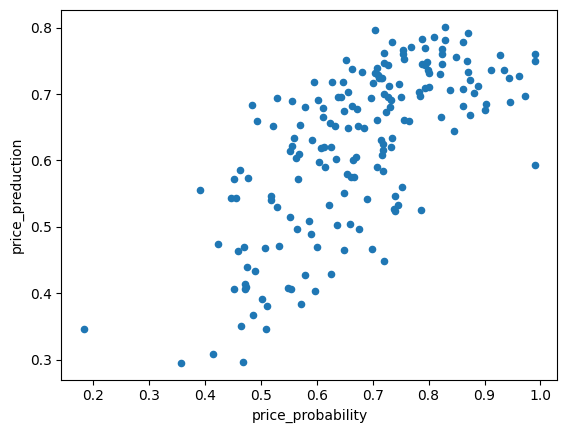

In [66]:
result.plot(kind='scatter',x='price_probability',y='price_preduction')